In [9]:
!pip -q install kiwipiepy nltk pandas pyarrow tqdm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 MB 12.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.9/5.9 MB 11.1 MB/s eta 0:00:00


In [10]:
# 폰트 캐시 삭제 후 재실행
!rm -rf ~/.cache/matplotlib
# 런타임 재시작 후 다시 실행

# TF-IDF 시각화
- 전통ML vs 딥러닝 비교
- 2021-2022 vs 2023-2025 구간 비교

## 패키지

In [11]:
import subprocess
import sys

def install_packages():
    packages = [
        'scikit-learn',
        'wordcloud',
        'networkx',
        'seaborn',
        'matplotlib',
        'pandas',
        'numpy'
    ]

    for package in packages:
        try:
            __import__(package.replace('-', '_'))
        except ImportError:
            subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', package])

install_packages()

## 한글 폰트 설정

In [12]:
subprocess.run(['apt-get', 'install', '-y', '-qq', 'fonts-nanum'],
               stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 나눔고딕 폰트 경로
FONT_PATH = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
font_prop = fm.FontProperties(fname=FONT_PATH)

## 임포트

In [13]:
import pandas as pd
import numpy as np
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.feature_extraction.text import TfidfVectorizer
from wordcloud import WordCloud
from collections import Counter, defaultdict
from itertools import combinations
import networkx as nx

## AI 분류 패턴

In [14]:
TRADITIONAL_ML_PATTERNS = [
    r'\bml\b', r'machine\s+learning', r'supervised\s+learning', r'unsupervised\s+learning',
    r'\bsvm\b', r'support\s+vector', r'random\s+forest', r'decision\s+tree',
    r'k-?nearest', r'\bknn\b', r'naive\s+bayes', r'logistic\s+regression',
    r'gradient\s+boosting', r'\bxgboost\b', r'\blightgbm\b',
    r'머신\s?러닝', r'기계\s?학습', r'지도\s?학습', r'비지도\s?학습',
]

DEEP_LEARNING_PATTERNS = [
    r'deep\s+learning', r'neural\s+network', r'\bcnn\b', r'\brnn\b', r'\blstm\b',
    r'\bgru\b', r'transformer', r'attention', r'\bbert\b', r'\bgpt\b',
    r'computer\s+vision', r'object\s+detection', r'\bgan\b', r'autoencoder',
    r'resnet', r'yolo', r'vgg', r'alexnet', r'inception',
    r'딥\s?러닝', r'심층\s?학습', r'신경망', r'합성곱', r'순환\s?신경망',
]

# 논문 AI 유형 분류
def classify_paper(row):
    import re

    kywd = str(row.get('KYWD', '')) if pd.notna(row.get('KYWD')) else ''
    title = str(row.get('NODE_TTLE_EN', '')) if pd.notna(row.get('NODE_TTLE_EN')) else ''
    abstract = str(row.get('ABST_EN', '')) if pd.notna(row.get('ABST_EN')) else ''

    text = (kywd + ' ' + title + ' ' + abstract).lower()

    for pattern in DEEP_LEARNING_PATTERNS:
        if re.search(pattern, text, re.IGNORECASE):
            return '딥러닝'

    for pattern in TRADITIONAL_ML_PATTERNS:
        if re.search(pattern, text, re.IGNORECASE):
            return '전통ML'

    return None

## 불용어 정의

In [15]:
KOREAN_STOPWORDS = {
    '것', '수', '등', '및', '이', '그', '저', '개', '명', '번', '위',
    '때', '년', '월', '일', '시', '분', '초', '곳', '데', '점',
    '연구', '분석', '결과', '방법', '제안', '제시', '개발', '설계',
    '적용', '활용', '이용', '사용', '구현', '시스템', '기술', '방식', '딥러닝', '딥', '러닝', '머신러닝', '머신', '러닝', '데이터', '성능',
    '개발', '모델', '확인', '다양', '알고리즘', '영향'
}

ENGLISH_STOPWORDS = {
    'the', 'of', 'and', 'to', 'in', 'is', 'for', 'with', 'as', 'by', 'on', 'at',
    'deep', 'learning', 'machine', 'neural', 'network', 'networks',
    'data', 'model', 'models', 'training', 'test', 'validation',
    'based', 'using', 'used', 'method', 'methods', 'approach',
    'performance', 'result', 'results', 'paper', 'study', 'research',
    'recent', 'however', 'show', 'suggest', 'verify',
    'complete', 'use', 'improve', 'provide', 'demonstrate',
    'various', 'include', 'system', 'technology', 'machine learning', 'machinelearning',
    'machine', 'deep learning', 'deeplearning', 'deep-learning', 'machine-learning', 'apply', 'algorithm', 'analysis', 'high',
    'variou', 'learn', 'analyze', 'technique', 'propose', 'proces', 'perform', 'compare', 'accuracy',
    'increase', 'prediction', 'exist', 'develop', 'influence', 'exprience'

}

ALL_STOPWORDS = KOREAN_STOPWORDS | ENGLISH_STOPWORDS

## 데이터 로드 및 전처리

In [16]:
def load_and_classify_data(parquet_file):

    df = pd.read_parquet(parquet_file)

    # 연도 추출
    df['PBSH'] = df['PBSH'].astype(str).str.strip()
    df['year'] = df['PBSH'].str.slice(0, 4).astype('Int64')

    # AI 유형 분류
    df['ai_type'] = df.apply(classify_paper, axis=1)

    # 분류된 논문만
    df_classified = df[df['ai_type'].notna()].copy()

    print(f"\n총 {len(df_classified):,}개 논문 분류")
    print(f"딥러닝: {(df_classified['ai_type'] == '딥러닝').sum():,}편")
    print(f"전통ML: {(df_classified['ai_type'] == '전통ML').sum():,}편\n")

    return df_classified

## TF-IDF 계산 함수

In [17]:
SEP = "<<<SEP>>>"

# 토큰 리스트를 문자열로 변환
def doc_from_tokens(tokens):
    if isinstance(tokens, np.ndarray):
        tokens = tokens.tolist()
    if not isinstance(tokens, list):
        return ""
    return SEP.join([str(t).strip() for t in tokens if str(t).strip()])

def sep_tokenizer(doc):
    return doc.split(SEP)

# 특정 AI 유형, 특정 기간의 TF-IDF 계산
def compute_period_tfidf(df_src, ai_type, year_from, year_to, top_k=80):

    sub = df_src[
        (df_src['ai_type'] == ai_type) &
        (df_src['year'] >= year_from) &
        (df_src['year'] <= year_to)
    ].copy()

    if len(sub) < 10:
        return pd.DataFrame(columns=['keyword', 'tfidf'])

    # 문서 생성
    docs = sub['merged_tokens_dedup'].apply(doc_from_tokens)

    # TF-IDF 벡터라이저
    vectorizer = TfidfVectorizer(
        tokenizer=sep_tokenizer,
        preprocessor=None,
        lowercase=False,
        token_pattern=None,
        min_df=2,
        max_df=0.85
    )

    X = vectorizer.fit_transform(docs)
    tfidf_mean = X.mean(axis=0).A1
    vocab = vectorizer.get_feature_names_out()

    out = (
        pd.DataFrame({'keyword': vocab, 'tfidf': tfidf_mean})
        .sort_values('tfidf', ascending=False)
        .head(top_k)
        .reset_index(drop=True)
    )

    return out

## 시각화 함수

In [18]:
# 구간별 막대 그래프
def plot_tfidf_comparison(tfidf_dict, ai_type, topk_bar=20):

    fig, axes = plt.subplots(1, 2, figsize=(18, 7))

    for ax, (period, kw_df) in zip(axes, tfidf_dict.items()):
        # 불용어 제거 후 Top20
        cleaned = kw_df[~kw_df['keyword'].isin(ALL_STOPWORDS)].copy()
        plot_df = cleaned.head(topk_bar).sort_values('tfidf', ascending=True)

        # 막대그래프
        ax.barh(plot_df['keyword'], plot_df['tfidf'], color='steelblue')
        ax.set_title(f"Top {topk_bar} Keywords by TF-IDF - {ai_type} ({period})",
                     fontproperties=font_prop, fontsize=14)
        ax.set_xlabel("Mean TF-IDF", fontproperties=font_prop)

        # Y축 라벨에 폰트 적용
        for tick in ax.get_yticklabels():
            tick.set_fontproperties(font_prop)

        # X축 라벨에 폰트 적용
        for tick in ax.get_xticklabels():
            tick.set_fontproperties(font_prop)

    plt.tight_layout()
    plt.savefig(f'tfidf_bar_{ai_type}.png', dpi=300, bbox_inches='tight')
    plt.show()

    print(f"저장: tfidf_bar_{ai_type}.png\n")

# 워드 클라우드 구간 비교
def plot_wordcloud_comparison(tfidf_dict, ai_type, wc_topn=120):

    fig, axes = plt.subplots(1, 2, figsize=(18, 7))

    for ax, (period, kw_df) in zip(axes, tfidf_dict.items()):

        # 불용어 제거
        cleaned = kw_df[~kw_df['keyword'].isin(ALL_STOPWORDS)].copy()
        cleaned = cleaned.head(wc_topn)

        # 빈도 딕셔너리
        freq = dict(zip(cleaned['keyword'], cleaned['tfidf']))

        # 워드클라우드 생성
        wc = WordCloud(
            width=900,
            height=600,
            background_color='white',
            font_path=FONT_PATH,
            max_words=wc_topn,
            collocations=False,
            colormap='viridis'
        ).generate_from_frequencies(freq)

        ax.imshow(wc, interpolation='bilinear')
        ax.axis('off')
        ax.set_title(f"WordCloud (TF-IDF) - {ai_type} ({period})",
                     fontproperties=font_prop, fontsize=14)

    plt.tight_layout()
    plt.savefig(f'wordcloud_{ai_type}.png', dpi=300, bbox_inches='tight')
    plt.show()

    print(f"저장: wordcloud_{ai_type}.png\n")

# 연도별 논문 수 추이
def plot_yearly_trend(df_classified):

    yearly = df_classified.groupby(['year', 'ai_type']).size().unstack(fill_value=0)

    fig, ax = plt.subplots(figsize=(10, 6))

    x = yearly.index
    width = 0.35

    if '전통ML' in yearly.columns:
        ax.bar(x - width/2, yearly['전통ML'], width, label='전통ML', alpha=0.8)
    if '딥러닝' in yearly.columns:
        ax.bar(x + width/2, yearly['딥러닝'], width, label='딥러닝', alpha=0.8)

    ax.set_xlabel('연도', fontproperties=font_prop)
    ax.set_ylabel('논문 수', fontproperties=font_prop)
    ax.set_title('연도별 AI 논문 수 추이', fontproperties=font_prop)
    ax.legend(prop=font_prop)

    # 축 라벨 폰트
    for tick in ax.get_xticklabels():
        tick.set_fontproperties(font_prop)
    for tick in ax.get_yticklabels():
        tick.set_fontproperties(font_prop)

    plt.tight_layout()
    plt.savefig('yearly_trend.png', dpi=300, bbox_inches='tight')
    plt.show()

    print("저장: yearly_trend.png\n")


## 메인


총 9,490개 논문 분류
딥러닝: 7,828편
전통ML: 1,662편

연도별 논문 수 추이


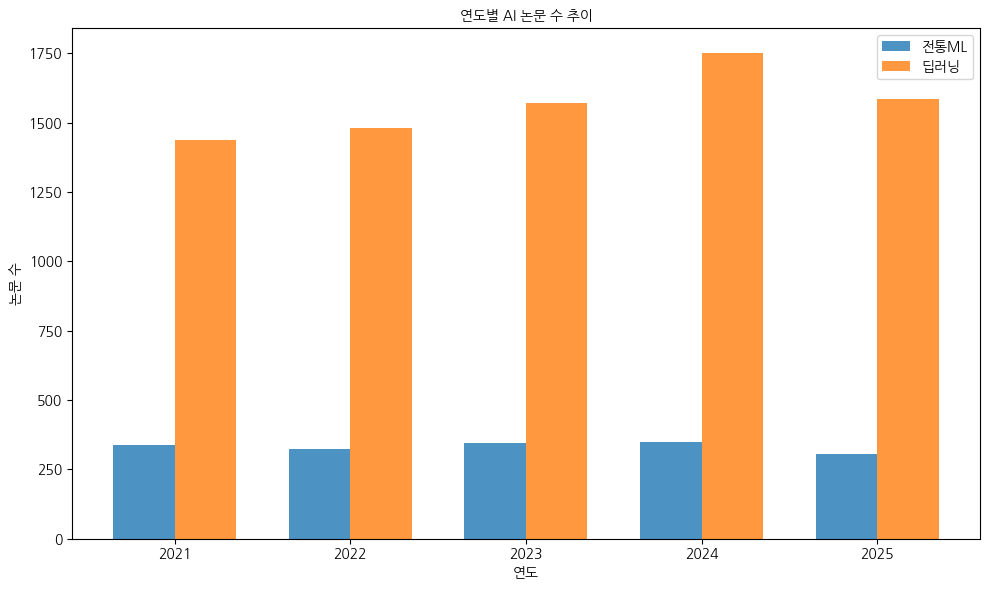

저장: yearly_trend.png



In [21]:
    # 데이터 로드
    df_classified = load_and_classify_data('df_tokens.parquet')

    # 연도별 추이 그래프
    print("연도별 논문 수 추이")
    plot_yearly_trend(df_classified)

전통ML TF-IDF 막대그래프


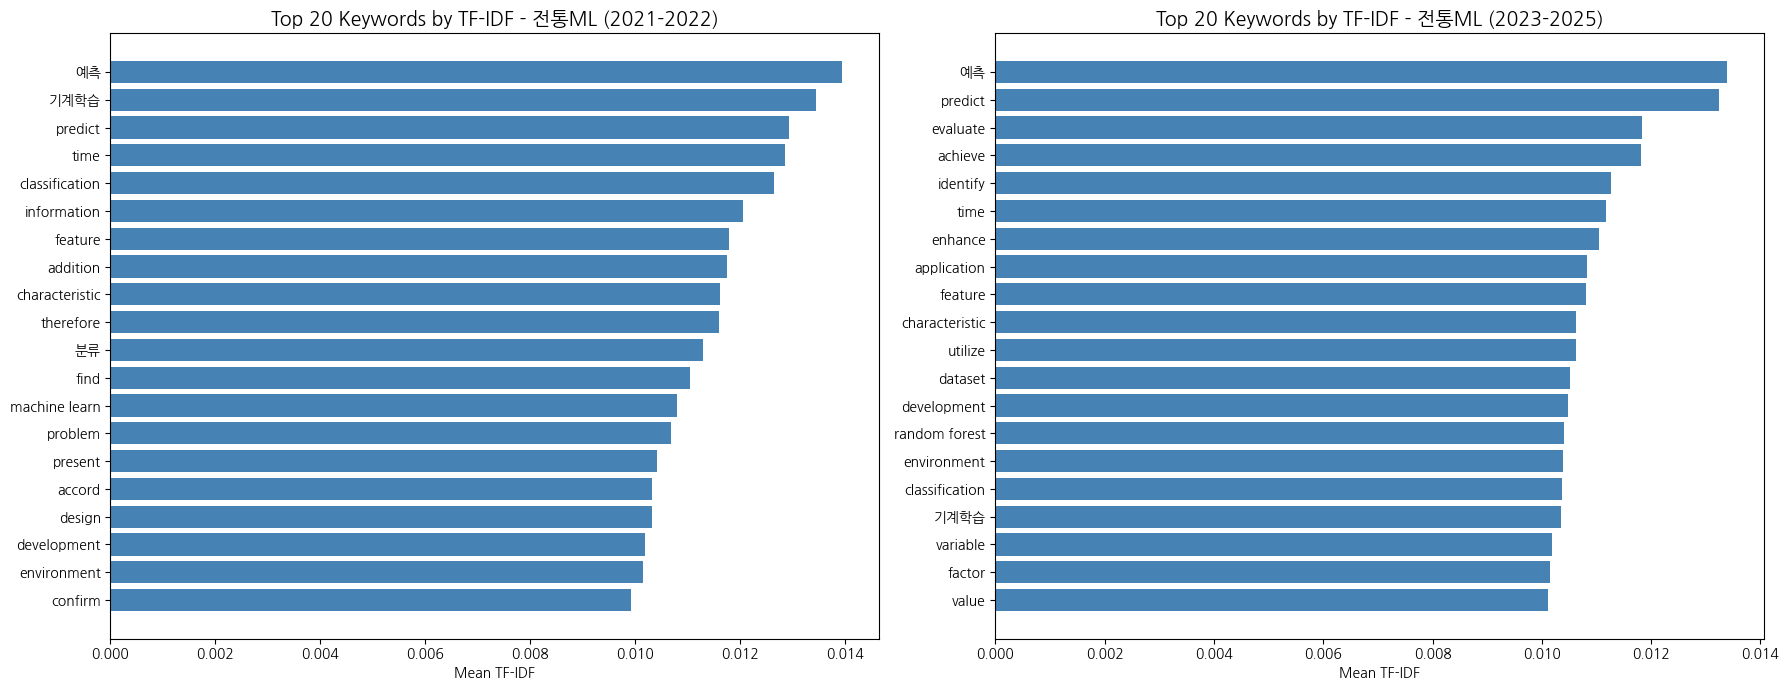

저장: tfidf_bar_전통ML.png

전통ML 워드클라우드


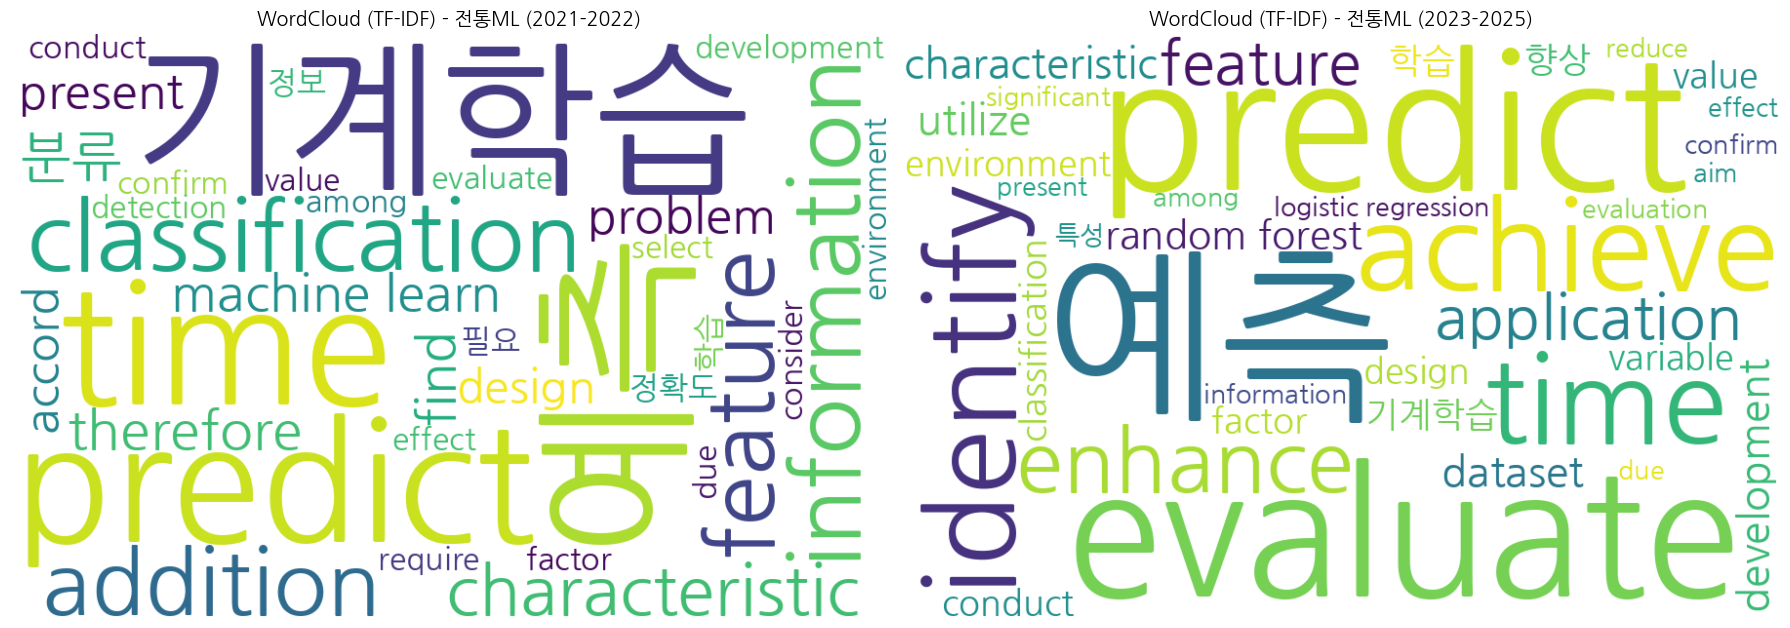

저장: wordcloud_전통ML.png

딥러닝 TF-IDF 막대그래프


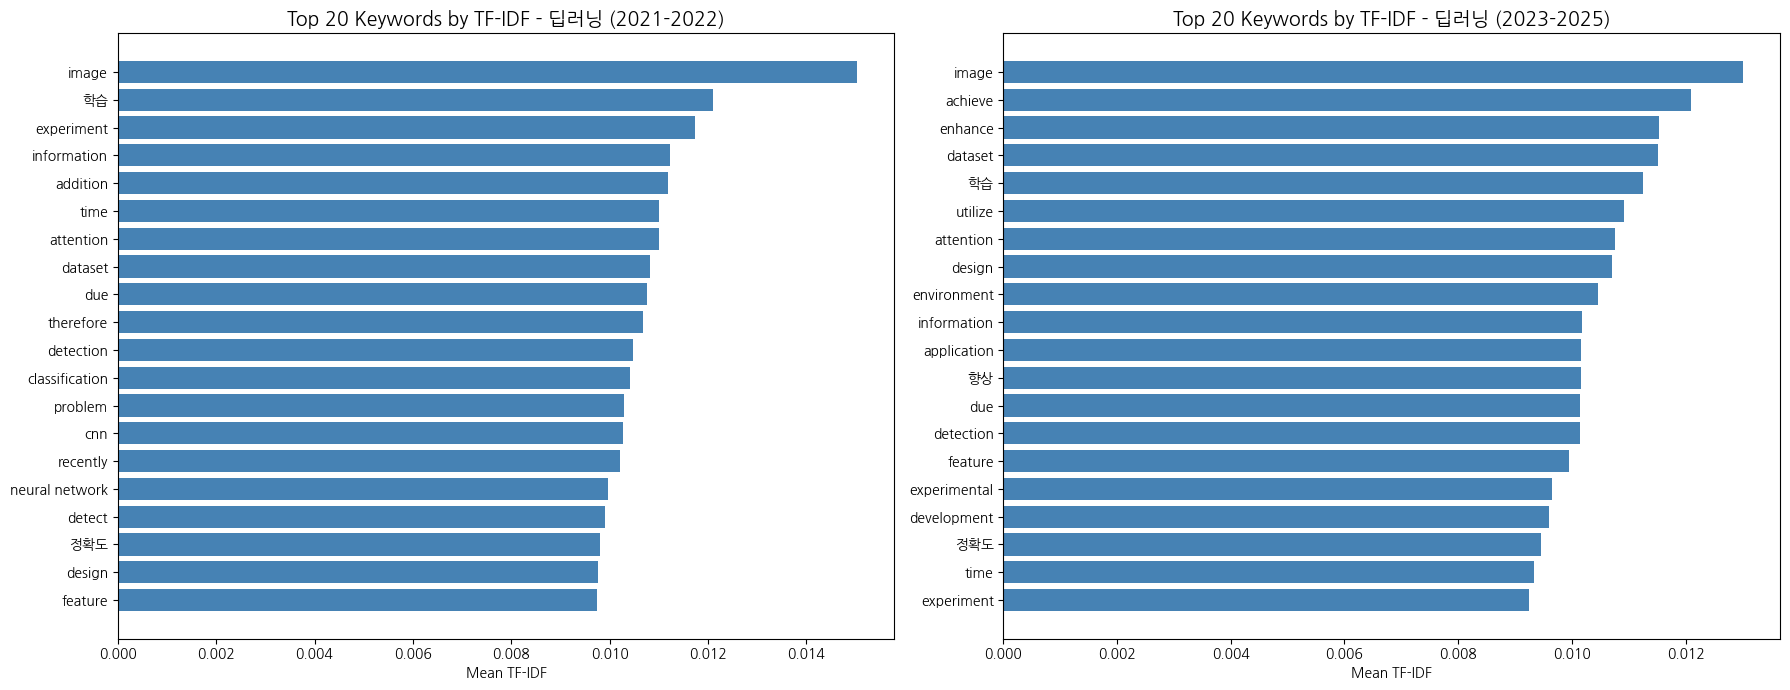

저장: tfidf_bar_딥러닝.png

딥러닝 워드클라우드


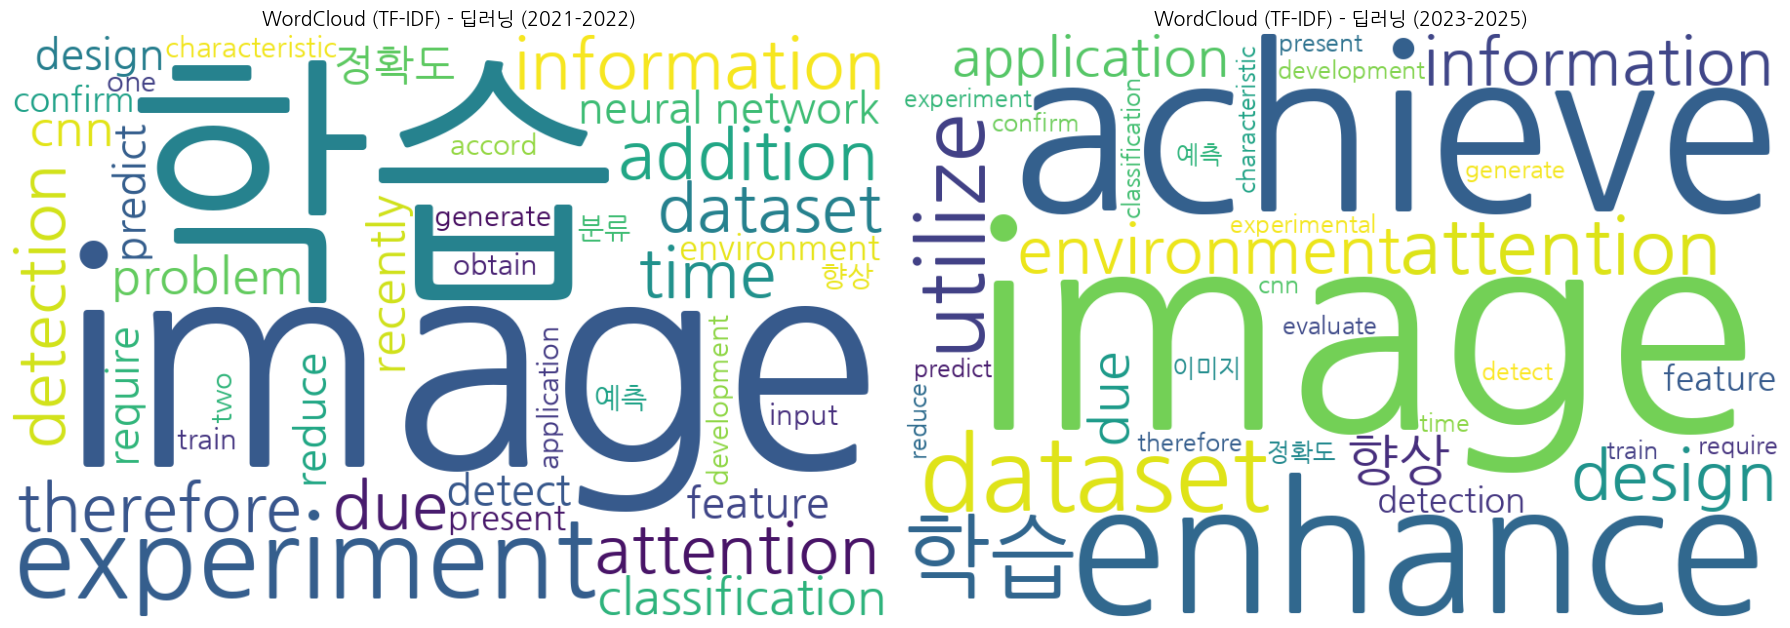

저장: wordcloud_딥러닝.png



In [22]:

    # 구간 정의
    PERIODS = {
        '2021-2022': (2021, 2022),
        '2023-2025': (2023, 2025)
    }

    # AI 유형별로 분석
    for ai_type in ['전통ML', '딥러닝']:

        # 구간별 TF-IDF 계산
        tfidf_by_period = {}
        for period, (y0, y1) in PERIODS.items():
            tfidf_by_period[period] = compute_period_tfidf(df_classified, ai_type, y0, y1)

        # 막대그래프
        print(f"{ai_type} TF-IDF 막대그래프")
        plot_tfidf_comparison(tfidf_by_period, ai_type, topk_bar=20)

        # 워드클라우드
        print(f"{ai_type} 워드클라우드")
        plot_wordcloud_comparison(tfidf_by_period, ai_type, wc_topn=120)